<a href="https://colab.research.google.com/github/dachishonia/fer-challenge/blob/main/notebooks/fer_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install wandb kaggle tqdm pyyaml scikit-learn seaborn -q

In [40]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

REPO = '/content/fer-challenge'

if not os.path.exists(REPO):
    !git clone https://github.com/dachishonia/fer-challenge.git $REPO
else:
    !git -C $REPO pull

sys.path.insert(0, REPO)
sys.path.insert(0, f'{REPO}/src')
print('Repo ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
Repo ready.


In [41]:
!git -C /content/fer-challenge pull

Already up to date.


In [42]:
import importlib
import dataset, models, train, utils

importlib.reload(dataset)
importlib.reload(models)
importlib.reload(train)
importlib.reload(utils)

from dataset import get_dataloaders, get_class_weights, EMOTION_LABELS
from models  import get_model, count_parameters
from train   import train_model, overfit_single_batch
from utils   import run_sanity_checks

print('Modules reloaded.')

Modules reloaded.


In [29]:
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_credentials = {
    "username": "davitishonia",   # <-- replace this
    "key": "KGAT_5ea9b4e1d64d98ae1e778bec0be65bbe"          # <-- paste your copied key here
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("kaggle.json created successfully!")

kaggle.json created successfully!


In [32]:
DATA_DIR = '/content/fer2013/fer2013'
CSV_PATH = f'{DATA_DIR}/fer2013.csv'

if not os.path.exists(CSV_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    !kaggle competitions download \
        -c challenges-in-representation-learning-facial-expression-recognition-challenge \
        -p {DATA_DIR}
    !unzip -q {DATA_DIR}/*.zip -d {DATA_DIR}
    print('Done.')
else:
    print('Already downloaded.')

Already downloaded.


In [33]:
import pandas as pd
df = pd.read_csv(CSV_PATH)
print(f'Rows   : {len(df)}')
print(f'Splits : {df["Usage"].value_counts().to_dict()}')

Rows   : 35887
Splits : {'Training': 28709, 'PublicTest': 3589, 'PrivateTest': 3589}


In [34]:
import wandb
wandb.login()  # It will ask for your API key — paste it here

True

In [35]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

from dataset import get_dataloaders, get_class_weights, EMOTION_LABELS
from models  import get_model, count_parameters
from train   import train_model, overfit_single_batch
from utils   import run_sanity_checks

Device : cuda
GPU    : Tesla T4


Total samples : 35887
Splits        : {'Training': 28709, 'PublicTest': 3589, 'PrivateTest': 3589}


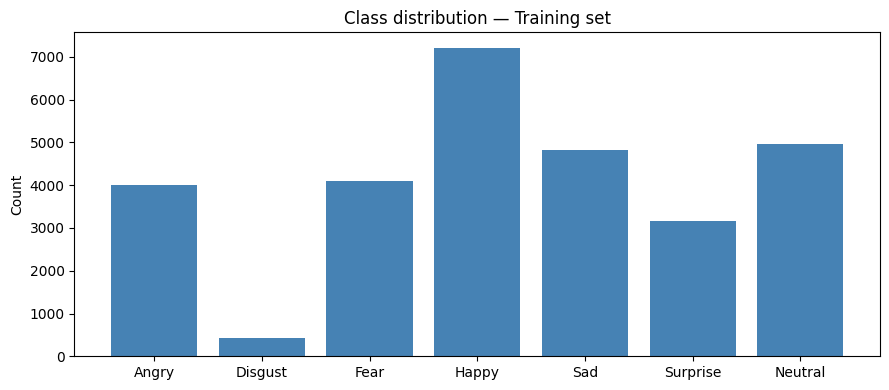

In [36]:
CSV_PATH = '/content/fer2013/fer2013/fer2013.csv'

df = pd.read_csv(CSV_PATH)
print(f'Total samples : {len(df)}')
print(f'Splits        : {df["Usage"].value_counts().to_dict()}')

train_df = df[df['Usage'] == 'Training']
counts = train_df['emotion'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(EMOTION_LABELS, counts.values, color='steelblue')
ax.set_title('Class distribution — Training set')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

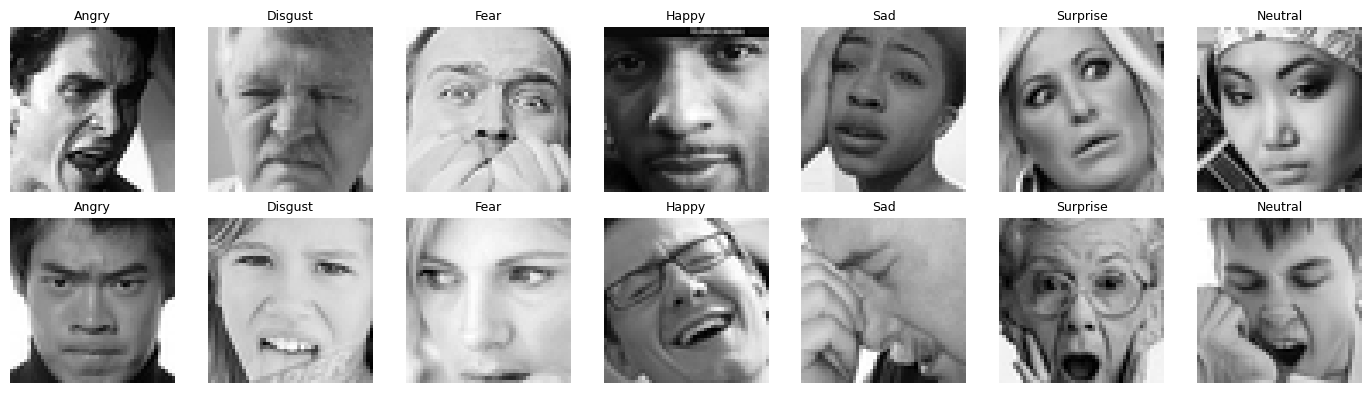

In [37]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for emotion_id in range(7):
    rows = train_df[train_df['emotion'] == emotion_id].sample(2, random_state=42)
    for row_idx, (_, row) in enumerate(rows.iterrows()):
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        axes[row_idx, emotion_id].imshow(pixels, cmap='gray')
        axes[row_idx, emotion_id].set_title(EMOTION_LABELS[emotion_id], fontsize=9)
        axes[row_idx, emotion_id].axis('off')
plt.tight_layout()
plt.show()

In [38]:
class_weights = get_class_weights(CSV_PATH)
for label, w in zip(EMOTION_LABELS, class_weights):
    print(f'  {label:10s}: {w:.3f}')

  Angry     : 0.480
  Disgust   : 4.398
  Fear      : 0.468
  Happy     : 0.266
  Sad       : 0.397
  Surprise  : 0.605
  Neutral   : 0.386
